<a href="https://colab.research.google.com/github/syedmahmoodiagents/MachineLearning/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
m = np.array([10,50,30,40,20])
n = np.array([40,0,15,70,35])

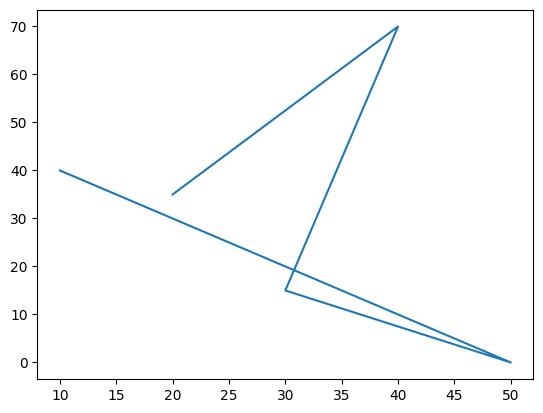

In [94]:
plt.plot(m,n)

In [1]:
import numpy as np
import pandas as pd

In [5]:
# !pip install mglearn --q

In [6]:
import matplotlib.pyplot as plt
import mglearn as mg

In [20]:
x = np.linspace(2,8,51)

In [9]:
fx = np.sin(x)

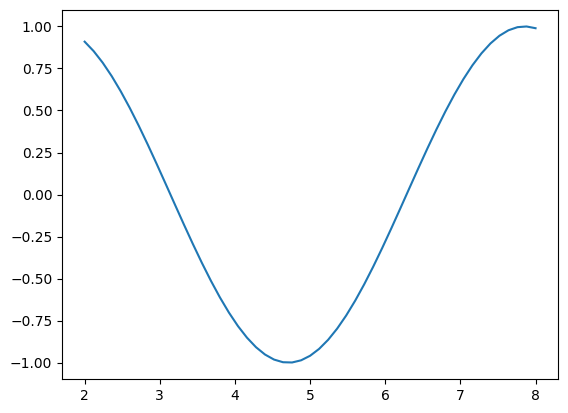

In [10]:
plt.plot(x,fx)

In [15]:
np.random.seed(101)
y = fx + np.random.normal(0,0.6,51)

In [39]:
Y = y.round(2)

In [40]:
Y

array([ 2.53,  1.23,  1.33,  1.01,  1.01,  0.32, -0.1 ,  0.66, -1.03,
        0.51,  0.26, -0.53, -0.18, -0.86, -1.07, -0.04, -0.59,  0.4 ,
        0.71, -0.5 , -0.77,  0.03, -2.02, -1.69, -1.07, -0.72, -0.82,
       -0.75, -0.31, -0.68, -0.25, -0.34, -0.73, -0.77, -0.77,  0.21,
       -0.03,  1.3 ,  0.42,  1.58, -0.1 ,  0.71,  0.  ,  0.77,  1.46,
        0.8 ,  0.93,  1.37,  2.29,  0.63,  0.54])

In [21]:
X = x.reshape(-1,1)

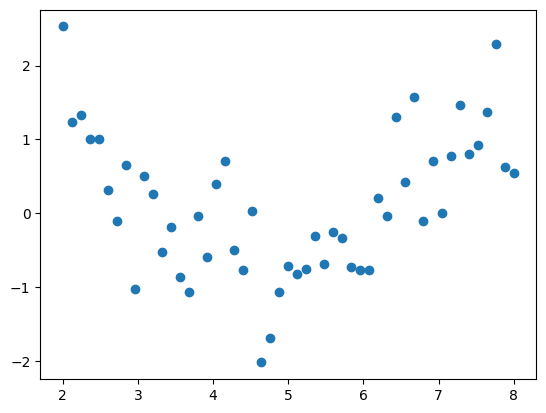

In [41]:
plt.scatter(X,Y)

In [100]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [42]:
model = DecisionTreeRegressor()

In [43]:
model.fit(X,Y)

DecisionTreeRegressor()

In [44]:
yp = model.predict(X)

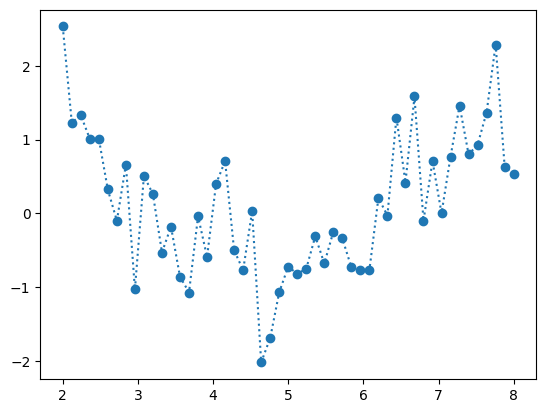

In [45]:
plt.scatter(x,y)
plt.plot(x, yp, ':')

# Train-Test Split

In [62]:
x = np.linspace(2,8,51)
fx = np.sin(x)
np.random.seed(101)
y = fx + np.random.normal(0,0.6,51)
Y = y.round(2)

In [26]:
from sklearn.model_selection import train_test_split

In [63]:
# list('abcdefghij')

In [64]:
# train_test_split([00,10,20,30,40,50,60,70,80,90], list('abcdefghij'))

In [65]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, random_state=41)

In [66]:
xtrain.shape

(38,)

In [77]:
train = np.hstack((xtrain.reshape(-1,1), ytrain.reshape(-1,1)))
test = np.hstack((xtest.reshape(-1,1), ytest.reshape(-1,1)))

In [78]:
dftrain = pd.DataFrame(train, columns=['x','y'])

In [79]:
dftest = pd.DataFrame(test, columns=['x','y'])

In [80]:
dftrain.sort_values(by='x', inplace=True)
dftest.sort_values(by='x', inplace=True)

In [82]:
dftrain['x'].values

array([2.  , 2.12, 2.24, 2.36, 2.48, 2.72, 3.32, 3.44, 3.56, 3.92, 4.04,
       4.28, 4.4 , 4.52, 4.64, 4.76, 4.88, 5.  , 5.12, 5.24, 5.36, 5.48,
       5.72, 5.84, 6.08, 6.2 , 6.32, 6.44, 6.68, 6.8 , 6.92, 7.04, 7.16,
       7.28, 7.4 , 7.64, 7.76, 7.88])

In [83]:
modl = DecisionTreeRegressor()

In [85]:
modl.fit(dftrain[['x']].values, dftrain['y'].values)

DecisionTreeRegressor()

In [86]:
yp_train = modl.predict(dftrain[['x']].values)
yp_test = modl.predict(dftest[['x']].values)

In [142]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [88]:
mean_squared_error(dftrain['y'].values, yp_train)

0.0

In [89]:
mean_squared_error(dftest['y'], yp_test)

0.38705081167194205

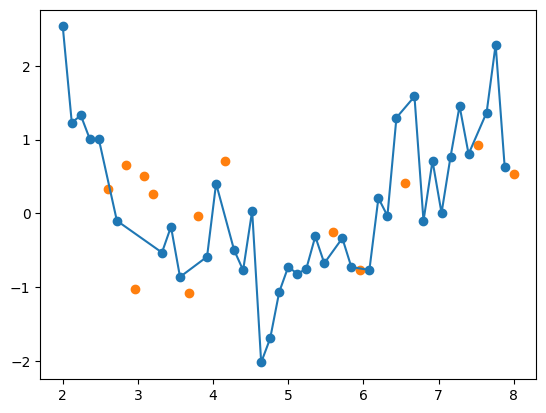

In [90]:
plt.scatter(dftrain['x'], dftrain['y'])
plt.scatter(dftest['x'], dftest['y'])
plt.plot(dftrain['x'], yp_train)


In [95]:
r2_score(dftrain['y'].values, yp_train)

1.0

In [97]:
r2_score(dftest['y'], yp_test)

0.07681579600479571

# Adding Changes

Text(0.2646551724137931, 0.8636363636363636, 'x[0] <= 2.6\nsquared_error = 0.912\nsamples = 27\nvalue = -0.211')

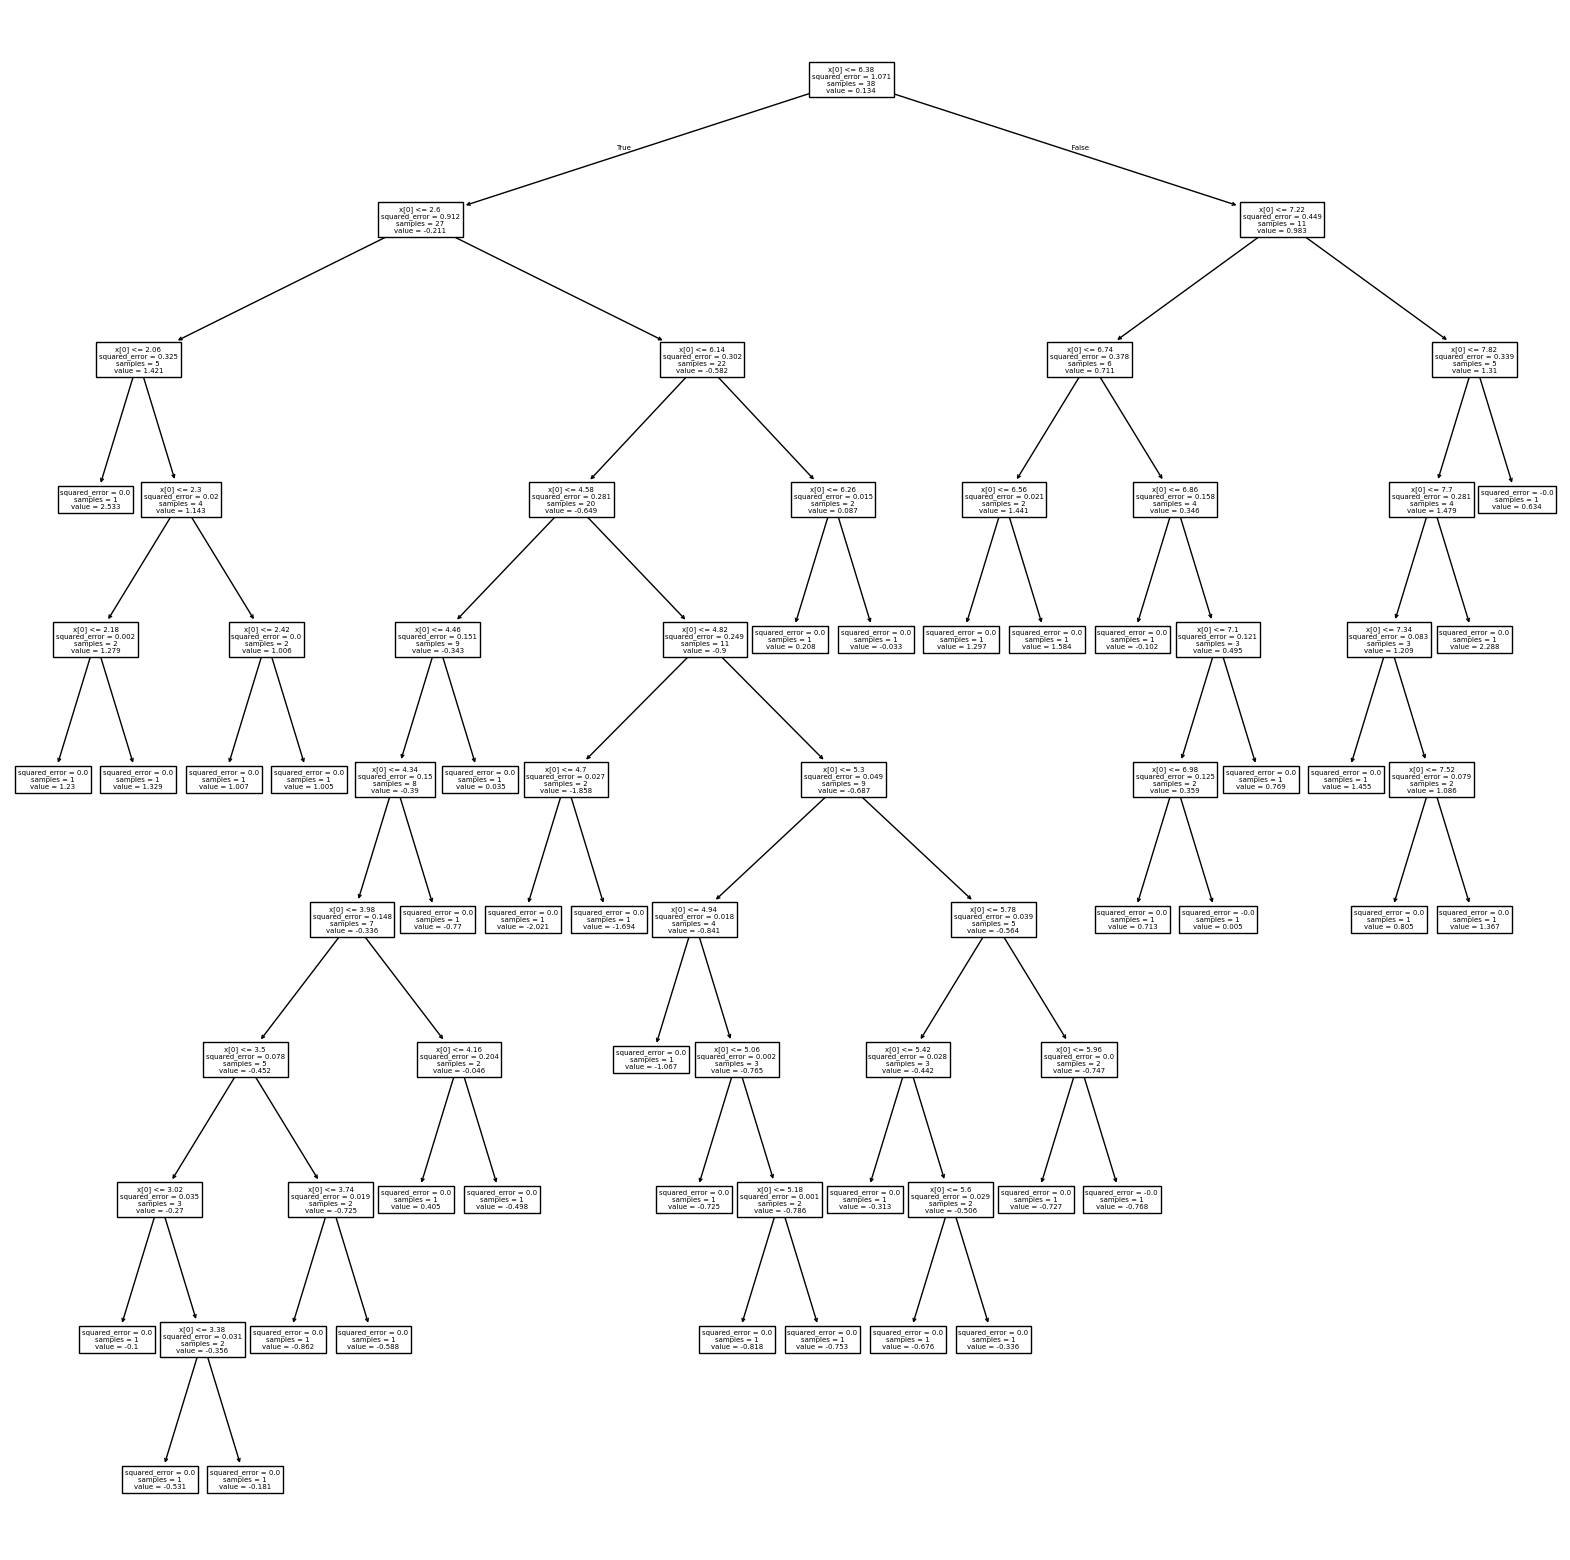

In [107]:
plt.figure(figsize=(20,20))
plot_tree(modl)[1]

In [108]:
mod1 = DecisionTreeRegressor(max_depth=3)

In [109]:
mod1.fit(dftrain[['x']].values, dftrain['y'].values)

DecisionTreeRegressor(max_depth=3)

In [111]:
yp_train1 = mod1.predict(dftrain[['x']].values)

In [112]:
yp_test1 = mod1.predict(dftest[['x']].values)

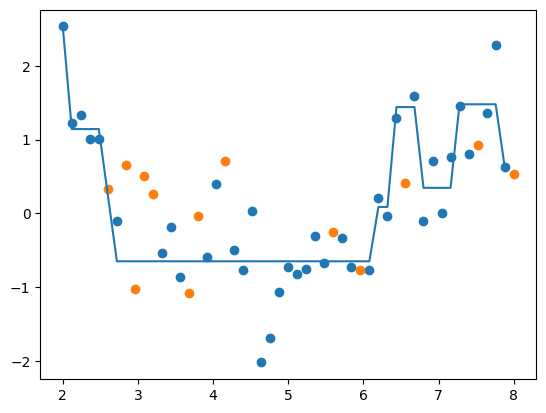

In [113]:
plt.scatter(dftrain['x'], dftrain['y'])
plt.scatter(dftest['x'], dftest['y'])
plt.plot(dftrain['x'], yp_train1)

In [114]:
r2_score(dftrain['y'].values, yp_train1)

0.815052168095041

In [115]:
r2_score(dftest['y'], yp_test1)

-0.5847447814130253

# Increasing the depth size

In [117]:
mod2 = DecisionTreeRegressor(max_depth=5)

In [118]:
mod2.fit(dftrain[['x']].values, dftrain['y'].values)

DecisionTreeRegressor(max_depth=5)

In [121]:
yp_train2 = mod2.predict(dftrain[['x']].values)
yp_test2 = mod2.predict(dftest[['x']].values)

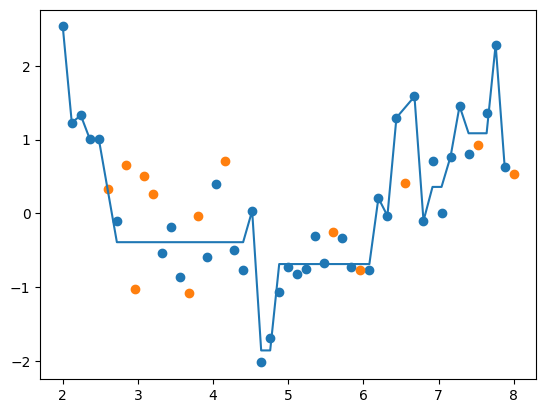

In [122]:
plt.scatter(dftrain['x'], dftrain['y'])
plt.scatter(dftest['x'], dftest['y'])
plt.plot(dftrain['x'], yp_train2)

In [123]:
r2_score(dftrain['y'].values, yp_train2)

0.9484654012137116

In [124]:
r2_score(dftest['y'], yp_test2)

-0.10430463408929458

In [125]:
mean_squared_error(dftrain['y'].values, yp_train2)

0.05521477434614065

In [126]:
mean_squared_error(dftest['y'], yp_test2)

0.462986696596001

# Trying with Multiple Decision Tree making it Random Forest

In [127]:
from sklearn.ensemble import RandomForestRegressor

In [128]:
randmodel = RandomForestRegressor(n_estimators=100)

In [129]:
randmodel.fit(dftrain[['x']].values, dftrain['y'].values)

RandomForestRegressor()

In [130]:
yp_rantrain = randmodel.predict(dftrain[['x']].values)
yp_rantest = randmodel.predict(dftest[['x']].values)

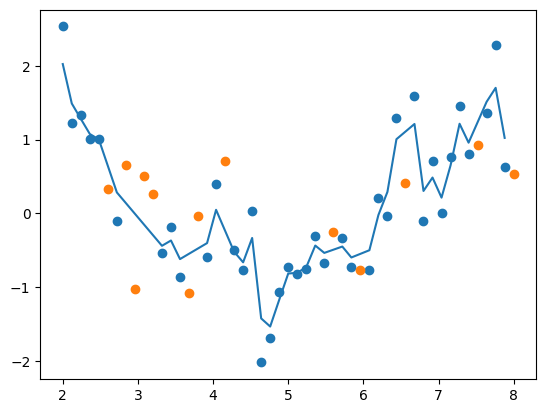

In [131]:
plt.scatter(dftrain['x'], dftrain['y'])
plt.scatter(dftest['x'], dftest['y'])
plt.plot(dftrain['x'], yp_rantrain)

In [132]:
r2_score(dftrain['y'].values, yp_rantrain)

0.9340371635163414

In [133]:
r2_score(dftest['y'], yp_rantest)

0.19903914612961526

# Restricting its depth

In [134]:
randmodel1 = RandomForestRegressor(n_estimators=100, max_depth=5)

In [135]:
randmodel1.fit(dftrain[['x']].values, dftrain['y'].values)

RandomForestRegressor(max_depth=5)

In [136]:
yp_rantrain1 = randmodel1.predict(dftrain[['x']].values)
yp_rantest1 = randmodel1.predict(dftest[['x']].values)

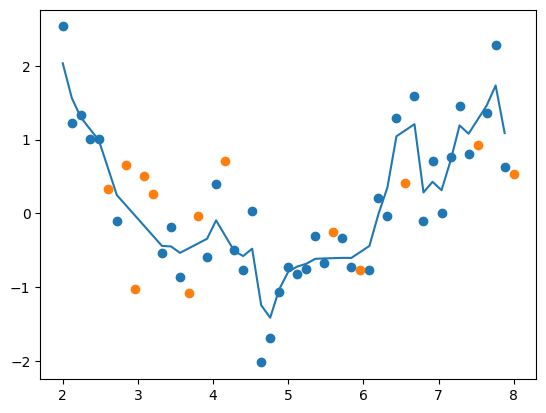

In [137]:
plt.scatter(dftrain['x'], dftrain['y'])
plt.scatter(dftest['x'], dftest['y'])
plt.plot(dftrain['x'], yp_rantrain1)

In [143]:
mean_absolute_percentage_error(dftrain['y'].values, yp_rantrain1)

2.9487636748747597

In [144]:
mean_absolute_percentage_error(dftest['y'], yp_rantest1)

1.9214450159480032

In [140]:
# r2_score(dftrain['y'].values, yp_rantrain1)

In [141]:
# r2_score(dftest['y'], yp_rantest1)

# Classifier

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
dt = load_iris()

In [ ]:
dt.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
X = dt.data

In [ ]:
Y = dt.target

In [ ]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
modl = DecisionTreeClassifier(criterion='entropy')

In [ ]:
modl.fit(X,Y)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
X.shape
Y.shape

(150,)

In [ ]:
# yp = modl.predict([[6.2, 2.9, 4.1 , 1.2]])
Yp = modl.predict(X)

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\nentropy = 1.585\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'entropy = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\nentropy = 1.0\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\nentropy = 0.445\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\nentropy = 0.146\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'entropy = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\nentropy = 0.918\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'entropy = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(

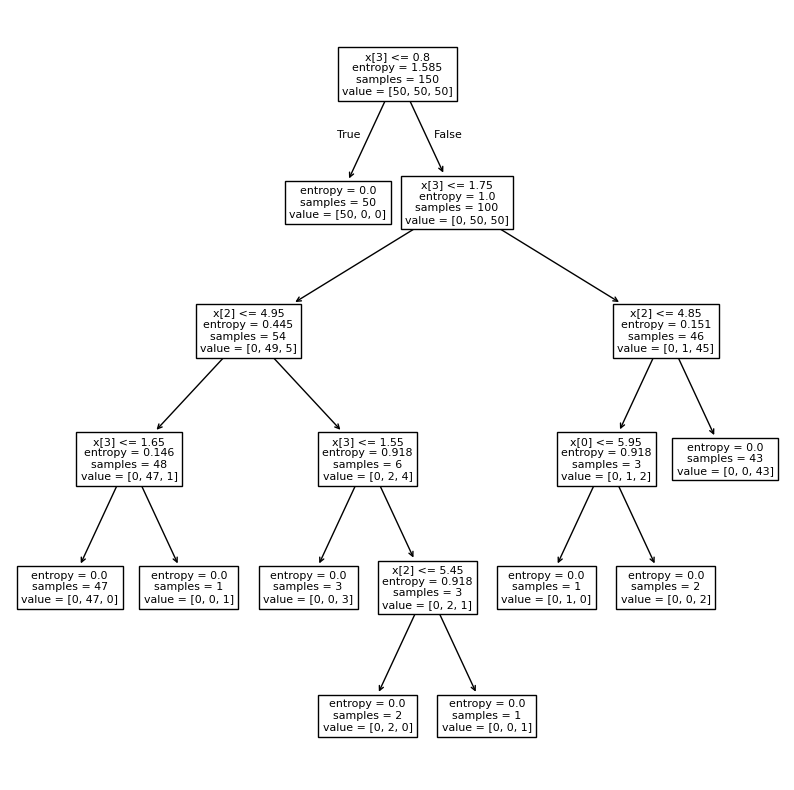

In [ ]:
plt.figure(figsize=(10,10))
plot_tree(modl)


In [ ]:
mrn = RandomForestClassifier(n_estimators=100)
mrn.fit(X,Y)

RandomForestClassifier()

In [ ]:
accuracy_score(Y, Yp)

1.0

In [ ]:
accuracy_score(Y, Yp)

1.0